# 只展示一半小提琴

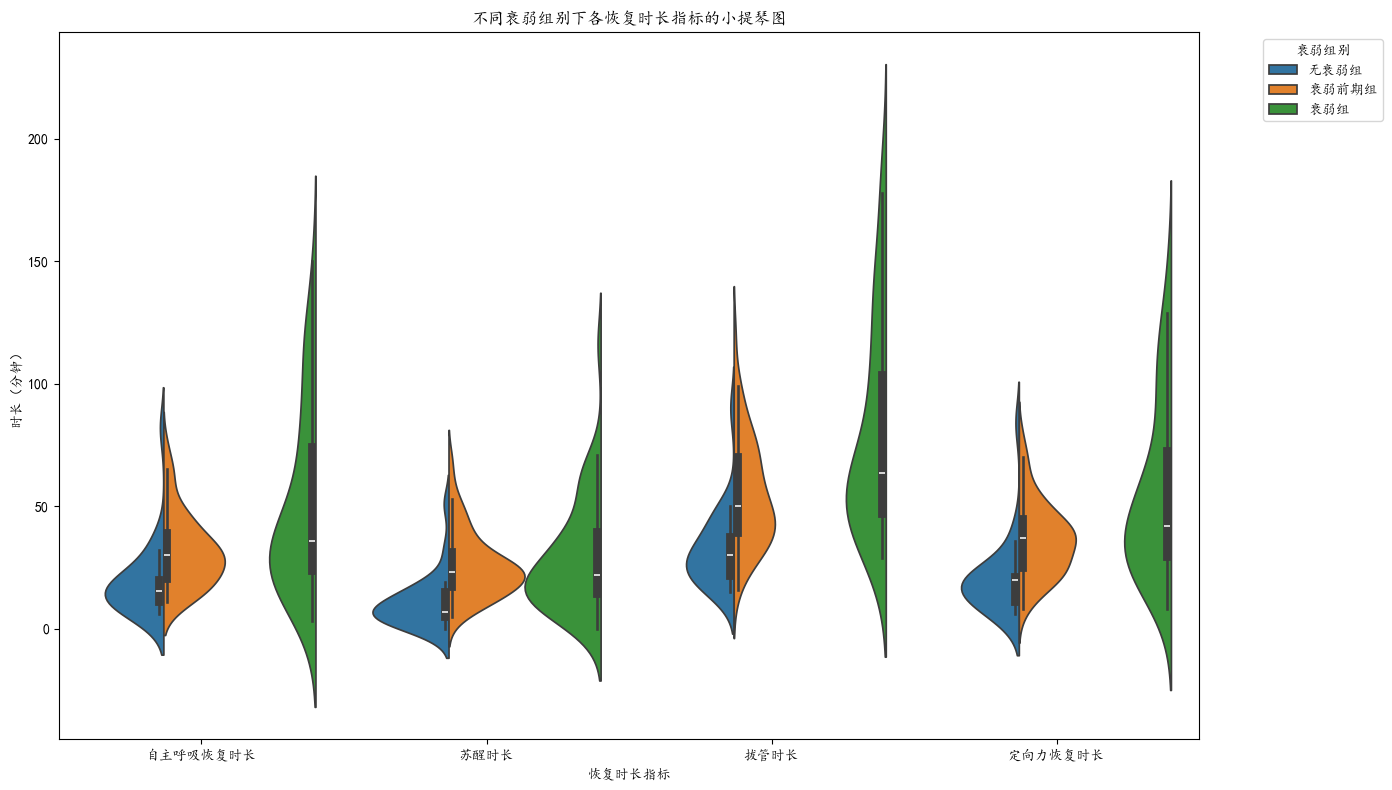

In [2]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# 读取数据
df = pd.read_csv('复苏时长.csv', encoding='utf-8')

# 创建衰弱组别
bins = [0, 1, 3, 5]
labels = ['无衰弱组', '衰弱前期组', '衰弱组']
df['衰弱组别'] = pd.cut(df['衰弱评分'], bins=bins, labels=labels, right=False, include_lowest=True)

# 转换数据为长格式
df_melted = df.melt(id_vars=['衰弱组别'],
value_vars=['自主呼吸恢复时长', '苏醒时长', '拔管时长', '定向力恢复时长'],
var_name='指标',
value_name='时长')

# 设置中文显示
plt.rcParams['font.sans-serif'] = ['SimHei']
plt.rcParams['axes.unicode_minus'] = False

# 绘制小提琴图
plt.figure(figsize=(14, 8))
sns.violinplot(x='指标', y='时长', hue='衰弱组别', data=df_melted, split=True)
plt.title('不同衰弱组别下各恢复时长指标的小提琴图')
plt.xlabel('恢复时长指标')
plt.ylabel('时长（分钟）')
plt.legend(title='衰弱组别', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.savefig('只展示一半小提琴.png', dpi=400, bbox_inches='tight')
plt.show()